In [88]:
import datetime as dt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import numpy as np


In [11]:
import arcticdb as adb
# this will set up the storage using the local file system
ac = adb.Arctic('lmdb:///home/roserahimi/PycharmProjects/Sproj/arctic_data')
tickers_lib = ac.get_library('individual_tickers', create_if_missing=True)

20260327 22:37:20.381061 1814395 W arcticdb | LMDB path at /home/roserahimi/PycharmProjects/Sproj/arctic_data/ has already been opened in this process which is not supported by LMDB. You should only open a single Arctic instance over a given LMDB path. To continue safely, you should delete this Arctic instance and any others over the LMDB path in this process and then try again. Current process ID=[1814395]


In [12]:
aapl = tickers_lib.read('AAPL').data
sci = tickers_lib.read('SCI').data
vsat = tickers_lib.read('VSAT').data
forty = tickers_lib.read('FORTY').data
M = tickers_lib.read('M').data
lpth = tickers_lib.read('LPTH').data
fdx = tickers_lib.read('FDX').data
cvbf = tickers_lib.read('CVBF').data
scvl = tickers_lib.read('SCVL').data

In [56]:
def calc_dailyReturn(stock, plotcheck=False):
    df = tickers_lib.read(stock).data
    dates_dt = df.index.get_level_values(level=0)
    df['returns'] = df['close'].pct_change().dropna()

    if plotcheck:
        plt.figure(stock+" price")
        plt.title(stock+" Returns")
        plt.xlabel("date")
        plt.ylabel("price in USD")
        plt.plot(dates_dt,df['returns'], alpha = 0.7, label = 'Returns')
        plt.show()
        plt.title(stock+" price")
        plt.plot(dates_dt,df['close'], alpha = 0.7, label = 'Close')
        plt.xlabel("date")
        plt.ylabel("price in USD")
        plt.legend()
        plt.show()
    return df['returns']

In [62]:
# this should tel you the actual performace throughout the time
def accumulativeReturns(returns, plotcheck=False):
    cum_returns = (1 + returns).cumprod()

    if plotcheck:
        plt.figure(figsize=(12, 4))
        plt.title("Cumulative Returns")
        plt.xlabel("date")
        plt.ylabel("Growth of $1")
        plt.plot(cum_returns.index, cum_returns, alpha=0.7, label='Cumulative Returns', color='green')
        plt.legend()
        plt.show()
    return cum_returns

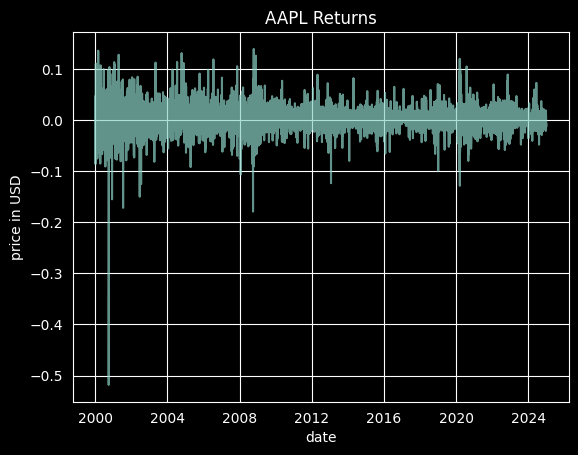

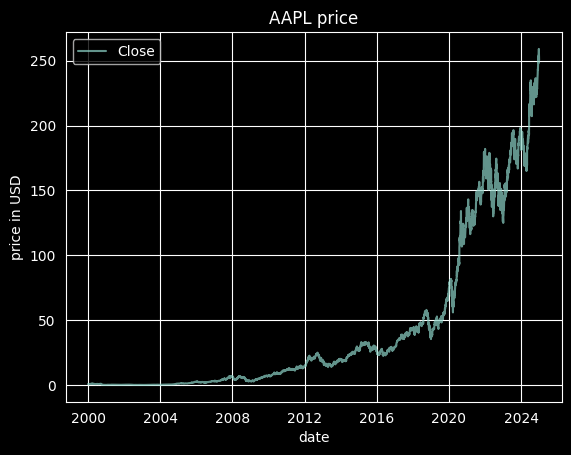

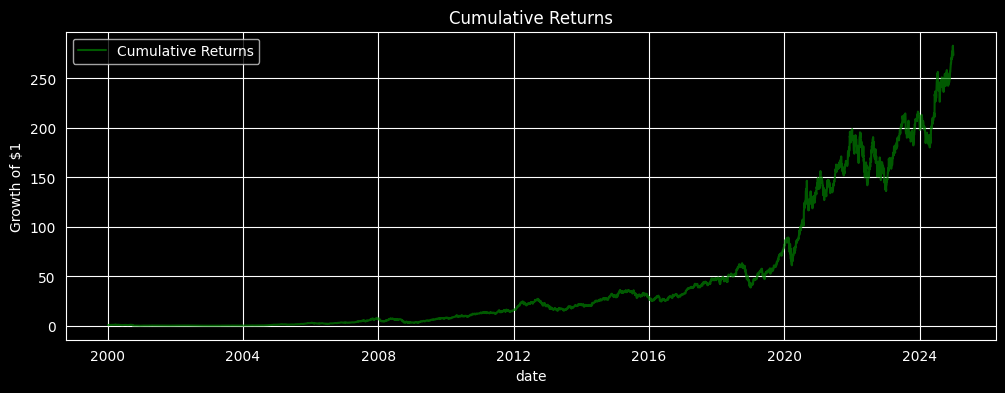

date
2000-01-04           NaN
2000-01-05      1.014208
2000-01-06      0.926776
2000-01-07      0.970492
2000-01-10      0.954098
                 ...    
2024-12-24    282.185792
2024-12-26    283.081967
2024-12-27    279.333333
2024-12-30    275.628415
2024-12-31    273.683060
Name: returns, Length: 6288, dtype: float64

In [63]:
returns = calc_dailyReturn('AAPL', plotcheck=True)
accumulativeReturns(returns, plotcheck=True)

In [64]:
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*10)

In [76]:
def plot_log_return_distributions(stocks, rows, cols, figsize=(1000, 800)):
    """
    Plot histogram distributions of log returns with annualized volatility
    for a list of stocks in a subplot grid.
    """
    if len(stocks) > rows * cols:
        raise ValueError(f"Grid {rows}x{cols} only fits {rows*cols} stocks, got {len(stocks)}")

    # Build log returns DataFrame
    logReturns = pd.DataFrame()
    for stock in stocks:
        df = tickers_lib.read(stock).data
        closedata = df['close']
        logReturns[stock] = np.log(closedata / closedata.shift(1)).dropna()

    # Annualized volatility
    annualize = logReturns.std() * np.sqrt(252)

    # Build subplots
    fig = make_subplots(
        rows=rows, cols=cols,
        subplot_titles=stocks
    )

    for idx, stock in enumerate(stocks):
        row, col = divmod(idx, cols)
        fig.append_trace(
            go.Histogram(
                x=logReturns[stock],
                name=stock,
                marker_color='steelblue',
                opacity=0.75
            ),
            row=row+1, col=col+1
        )
        fig.update_xaxes(
            title_text=f'Ann. Vol: {np.round(annualize[stock] * 100, 1)}%',
            row=row+1, col=col+1
        )
        fig.update_yaxes(
            title_text='Frequency',
            row=row+1, col=col+1
        )

    fig.update_layout(
        title='Log Return Distributions',
        autosize=False,
        height=figsize[1],
        width=figsize[0],
        showlegend=False,
        template='plotly_dark'
    )

    fig.show()
    return logReturns, annualize

In [84]:
stocks = ["AAPL", "MSFT", "IBM", "AMZN"]
log_returns, vols = plot_log_return_distributions(stocks, rows=3, cols=2)

In [89]:
# vol over 21 days
tradingDays = 21
volOverPeriod = logReturns.rolling(window=tradingDays).std() * np.sqrt(tradingDays)
fig_vol = px.line(volOverPeriod, title='Volatility over period')
fig_vol.update_layout(
    autosize=False,
    xaxis_title='Date',
    yaxis_title='Volatility'
)
fig_vol.show()